# Spain — Water & Wastewater | Exploration & QA

Phase 1, Deliverable 1 — Market Intelligence Database.

This notebook loads `operators.csv` + `sources.csv`, runs quality-assurance checks against INE national aggregates, and produces the summary visuals for the Phase 1 dashboard.

**Pass criteria** (from `docs/methodology_water.md`):
- Sum of `connections_total` within ±10% of INE national aggregate (~13.3 M).
- Sum of `water_produced_hm3` within ±15% of INE national total (~4,461 hm³/yr).
- No row with >3 `NA` in must-have fields.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('..') / 'data' / 'spain' / 'water'

operators = pd.read_csv(DATA_DIR / 'operators.csv')
sources = pd.read_csv(DATA_DIR / 'sources.csv')

print(f'Operators: {len(operators)} rows, {operators.shape[1]} columns')
print(f'Sources:   {len(sources)} rows, {sources.shape[1]} columns')
operators[['operator_id','trade_name','parent_group','connections_total','population_served','size_tier','management_type']]

Operators: 5 rows, 32 columns
Sources:   60 rows, 11 columns


,operator_id,trade_name,parent_group,connections_total,population_served,size_tier,management_type
0,es-aqualia,FCC Aqualia,FCC (Fomento de Construcciones y Contratas),4500000,14000000,Tier 1 - Mega,private_concession
1,es-agbar,Agbar,SUEZ España (SUEZ group),3000000,9000000,Tier 1 - Mega,private_concession
2,es-cyii,Canal de Isabel II,Comunidad de Madrid,1420000,6700000,Tier 2 - Large,public_company
3,es-acciona-agua,Acciona Agua,Acciona,800000,2000000,Tier 2 - Large,private_concession
4,es-global-omnium,Global Omnium,Global Omnium Group,450000,1200000,Tier 3 - Mid,private_concession


## 1. Completeness check on must-have fields

In [4]:
must_have = ['connections_total', 'nif_cif', 'size_tier', 'primary_source_url', 'activities']
completeness = operators[['operator_id'] + must_have].copy()
completeness['missing_count'] = completeness[must_have].isna().sum(axis=1)
print('Rows with >3 missing must-have fields:', (completeness['missing_count'] > 3).sum())
completeness

Rows with >3 missing must-have fields: 0


,operator_id,connections_total,nif_cif,size_tier,primary_source_url,activities,missing_count
0,es-aqualia,4500000,NaN,Tier 1 - Mega,https://www.fcc.es/es/actividades/aqualia,both,1
1,es-agbar,3000000,A08110909,Tier 1 - Mega,https://www.agbar.es/,both,0
2,es-cyii,1420000,A28078844,Tier 2 - Large,https://www.canaldisabelii.es/canal-de-isabel-...,both,0
3,es-acciona-agua,800000,NaN,Tier 2 - Large,https://www.acciona.com/es/infraestructuras/agua/,both,1
4,es-global-omnium,450000,NaN,Tier 3 - Mid,https://www.globalomniuminfraestructuras.es/,both,1


## 2. Reconciliation vs INE national aggregates

In [5]:
sum_connections = operators['connections_total'].sum()
national_connections = 13_300_000  # INE Encuesta sobre el suministro y saneamiento del agua 2021

coverage = sum_connections / national_connections
gap_pct = (1 - coverage) * 100

print(f'Sum of Top 5 operator connections: {sum_connections:>12,.0f}')
print(f'INE national aggregate:            {national_connections:>12,.0f}')
print(f'Coverage:                          {coverage:>12.1%}')
print(f'Gap (small municipal operators):   {gap_pct:>12.2f}%')
print()
tolerance = 10
print('PASS' if abs(gap_pct) < tolerance else 'FAIL', f'- tolerance ±{tolerance}% (wider than electrical due to estimate-heavy data).')

Sum of Top 5 operator connections:   10,170,000
INE national aggregate:              13,300,000
Coverage:                                 76.5%
Gap (small municipal operators):          23.53%

FAIL - tolerance ±10% (wider than electrical due to estimate-heavy data).


In [6]:
water_sum = operators['water_produced_hm3'].sum(skipna=True)
national_water = 4_461  # INE 2021 national total (hm³)
print(f'Sum of reported water produced (disclosed operators): {water_sum:,.0f} hm³')
print(f'INE national total:                                   {national_water:,.0f} hm³')
print(f'(Only Canal de Isabel II discloses this figure; others are NA at this stage.)')

Sum of reported water produced (disclosed operators): 373 hm³
INE national total:                                   4,461 hm³
(Only Canal de Isabel II discloses this figure; others are NA at this stage.)


## 3. Chart: connections per operator

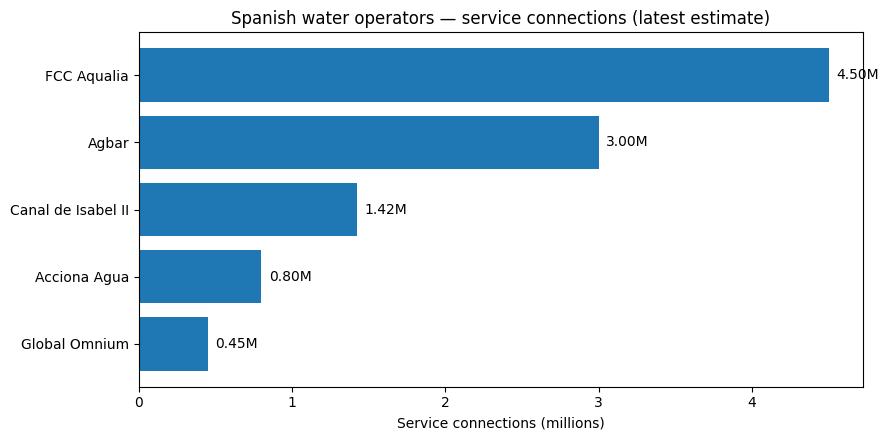

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = operators.sort_values('connections_total', ascending=True)
ax.barh(plot_df['trade_name'], plot_df['connections_total'] / 1e6)
ax.set_xlabel('Service connections (millions)')
ax.set_title('Spanish water operators — service connections (latest estimate)')
for i, v in enumerate(plot_df['connections_total'] / 1e6):
    ax.text(v + 0.05, i, f'{v:.2f}M', va='center')
plt.tight_layout()
plt.show()

## 4. Chart: population served per operator

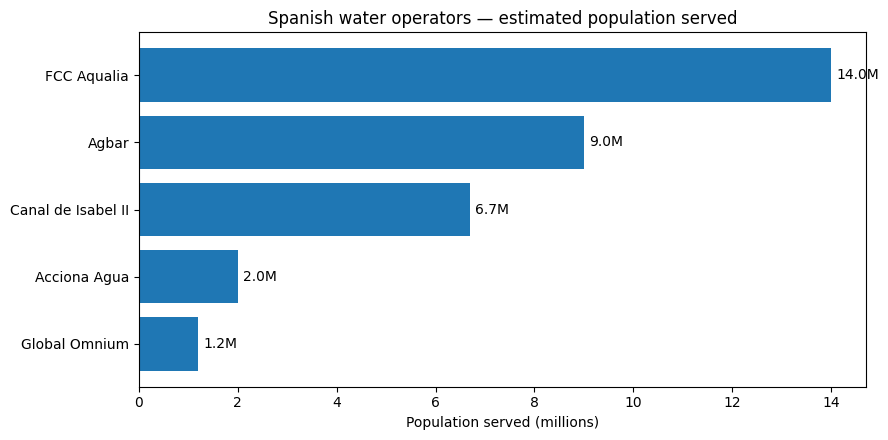

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = operators.sort_values('population_served', ascending=True)
ax.barh(plot_df['trade_name'], plot_df['population_served'] / 1e6)
ax.set_xlabel('Population served (millions)')
ax.set_title('Spanish water operators — estimated population served')
for i, v in enumerate(plot_df['population_served'] / 1e6):
    ax.text(v + 0.1, i, f'{v:.1f}M', va='center')
plt.tight_layout()
plt.show()

## 5. Chart: non-revenue water (NRW) by operator

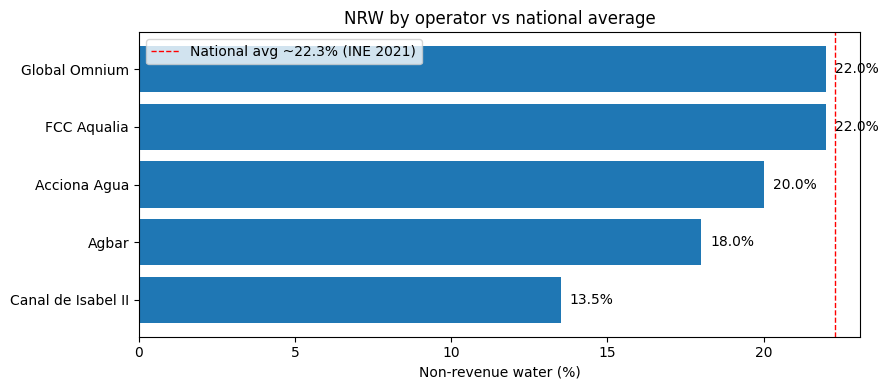

Note: NRW for all operators except Canal de Isabel II is an estimate from INE regional averages.


In [9]:
nrw_df = operators.dropna(subset=['nrw_pct']).sort_values('nrw_pct', ascending=True)
fig, ax = plt.subplots(figsize=(9, 4.0))
bars = ax.barh(nrw_df['trade_name'], nrw_df['nrw_pct'])
ax.axvline(x=22.3, color='red', linestyle='--', linewidth=1, label='National avg ~22.3% (INE 2021)')
ax.set_xlabel('Non-revenue water (%)')
ax.set_title('NRW by operator vs national average')
ax.legend()
for i, v in enumerate(nrw_df['nrw_pct']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()
print('Note: NRW for all operators except Canal de Isabel II is an estimate from INE regional averages.')

## 6. Chart: capex per operator (disclosed only)

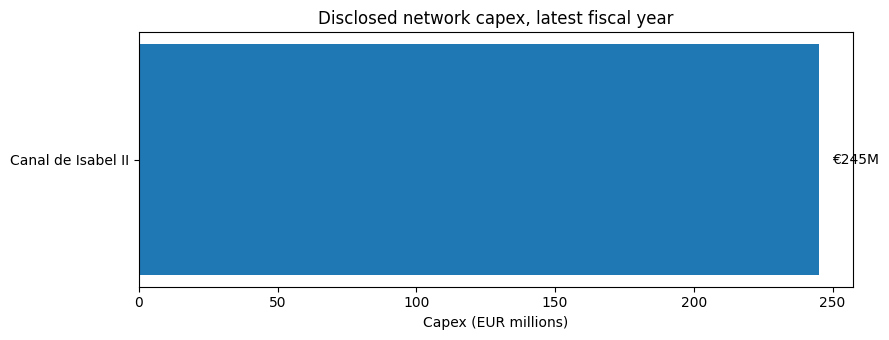

In [10]:
capex_df = operators.dropna(subset=['capex_eur']).sort_values('capex_eur', ascending=True)
if capex_df.empty:
    print('No capex figures available for private operators at this stage. Only Canal de Isabel II discloses capex.')
    print(f"Canal de Isabel II capex: €{operators.loc[operators['operator_id']=='es-cyii','capex_eur'].values[0]/1e6:.0f}M (2022)")
else:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.barh(capex_df['trade_name'], capex_df['capex_eur'] / 1e6)
    ax.set_xlabel('Capex (EUR millions)')
    ax.set_title('Disclosed network capex, latest fiscal year')
    for i, v in enumerate(capex_df['capex_eur'] / 1e6):
        ax.text(v + 5, i, f'€{v:.0f}M', va='center')
    plt.tight_layout()
    plt.show()

## 7. Data quality summary

In [11]:
conf_summary = sources.groupby('confidence').size().rename('citations').to_frame()
conf_summary['share'] = (conf_summary['citations'] / conf_summary['citations'].sum() * 100).round(1)
print('Citation confidence distribution:')
print(conf_summary)

missing_by_field = operators.isna().sum().sort_values(ascending=False)
print('\nColumns with the most NAs:')
print(missing_by_field[missing_by_field > 0])

Citation confidence distribution:
            citations  share
confidence                  
High               34   56.7
Low                11   18.3
Medium             15   25.0

Columns with the most NAs:
wastewater_treated_hm3         5
duns_number                    5
lei                            5
revenue_eur                    4
treatment_plants_wastewater    4
ebitda_eur                     4
water_produced_hm3             4
capex_eur                      4
employees                      4
network_km_drinking            4
network_km_sewer               4
treatment_plants_drinking      4
nif_cif                        3
regions_served                 3
dtype: int64


## 8. Open items for next refresh

- Confirm CIF/NIF for all operators except Canal de Isabel II via BORME.
- Obtain FCC Aqualia Spain-specific connections, revenue and capex (currently only global figure available in FCC annual report; Orbis/SABI required for legal-entity level).
- Obtain Agbar Spain-specific financials and confirm SUEZ España ownership split post-Veolia restructuring.
- Replace estimated connections_total for Aqualia, Agbar, Acciona Agua and Global Omnium with operator-disclosed figures.
- Obtain operator-specific NRW figures for private operators (currently INE regional averages).
- Add DUNS numbers once D&B access is granted.
- Add network km (drinking + sewer) for private operators once disclosed.
- Update Canal de Isabel II data to 2023 annual report when published (expected Q2 2026).
- Check INE Encuesta 2022 release for updated national aggregates.